In [95]:
!pip install yfinance seaborn scipy

# Bitcoin Correlation Analysis

This notebook analyzes the relationship between Bitcoin, the S&P 500, and Gold using data science techniques. The goal is to determine whether Bitcoin behaves more like a risk asset or a safe-haven asset.

## Data Collection

In [96]:
import yfinance as yf
import pandas as pd

start_date = "2020-01-01"
end_date = "2026-03-31"

btc = yf.download("BTC-USD", start=start_date, end=end_date)
sp500 = yf.download("^GSPC", start=start_date, end=end_date)
gold = yf.download("GC=F", start=start_date, end=end_date)

btc.head()

/tmp/ipykernel_1799/1551513219.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1799/1551513219.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1799/1551513219.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("GC=F", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


## Data Preparation and Enrichment

In [97]:
btc_close = btc['Close'].squeeze()
sp500_close = sp500['Close'].squeeze()
gold_close = gold['Close'].squeeze()

if isinstance(btc_close, pd.DataFrame):
    btc_close = btc_close.iloc[:, 0]

if isinstance(sp500_close, pd.DataFrame):
    sp500_close = sp500_close.iloc[:, 0]

if isinstance(gold_close, pd.DataFrame):
    gold_close = gold_close.iloc[:, 0]

btc_close.name = 'BTC'
sp500_close.name = 'SP500'
gold_close.name = 'Gold'
data = pd.concat([btc_close, sp500_close, gold_close], axis=1)
data = data.ffill().dropna()
returns = data.pct_change().dropna()

print(data.head())
print(data.columns)
print(type(returns['BTC']))

                    BTC        SP500         Gold
Date                                             
2020-01-02  6985.470215  3257.850098  1524.500000
2020-01-03  7344.884277  3234.850098  1549.199951
2020-01-04  7410.656738  3234.850098  1549.199951
2020-01-05  7411.317383  3234.850098  1549.199951
2020-01-06  7769.219238  3246.280029  1566.199951
Index(['BTC', 'SP500', 'Gold'], dtype='object')
<class 'pandas.core.series.Series'>


In [98]:
print(data.index.min())
print(data.index.max())
print(data.shape)
print(data.head())

2020-01-02 00:00:00
2026-03-30 00:00:00
(2280, 3)
                    BTC        SP500         Gold
Date                                             
2020-01-02  6985.470215  3257.850098  1524.500000
2020-01-03  7344.884277  3234.850098  1549.199951
2020-01-04  7410.656738  3234.850098  1549.199951
2020-01-05  7411.317383  3234.850098  1549.199951
2020-01-06  7769.219238  3246.280029  1566.199951


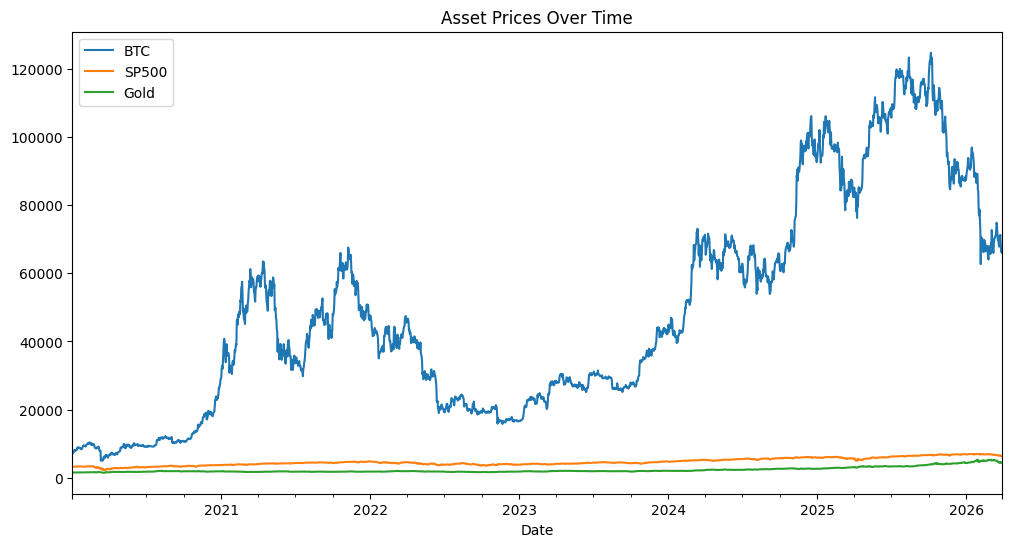

In [99]:
import matplotlib.pyplot as plt

data.plot(figsize=(12,6))
plt.title("Asset Prices Over Time")
plt.show()

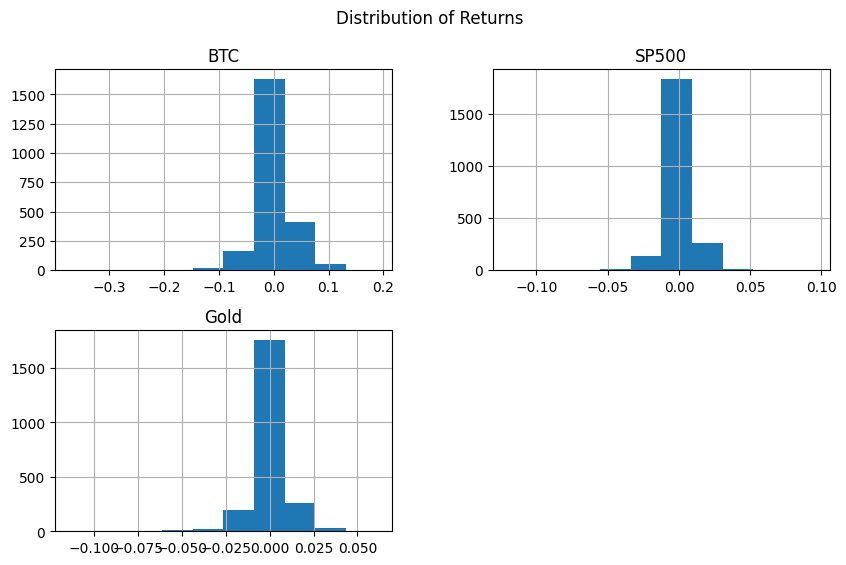

In [100]:
returns.hist(figsize=(10,6))
plt.suptitle("Distribution of Returns")
plt.show()

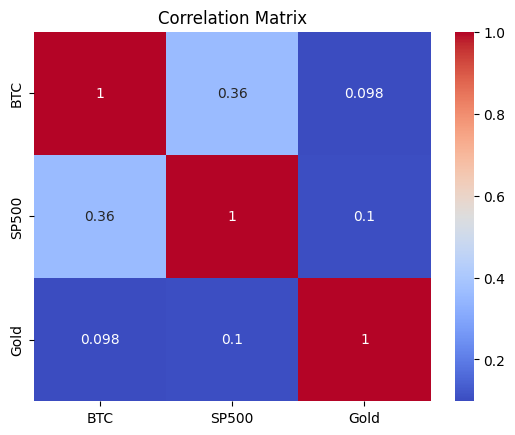

In [101]:
import seaborn as sns

sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Rolling Correlation Analysis

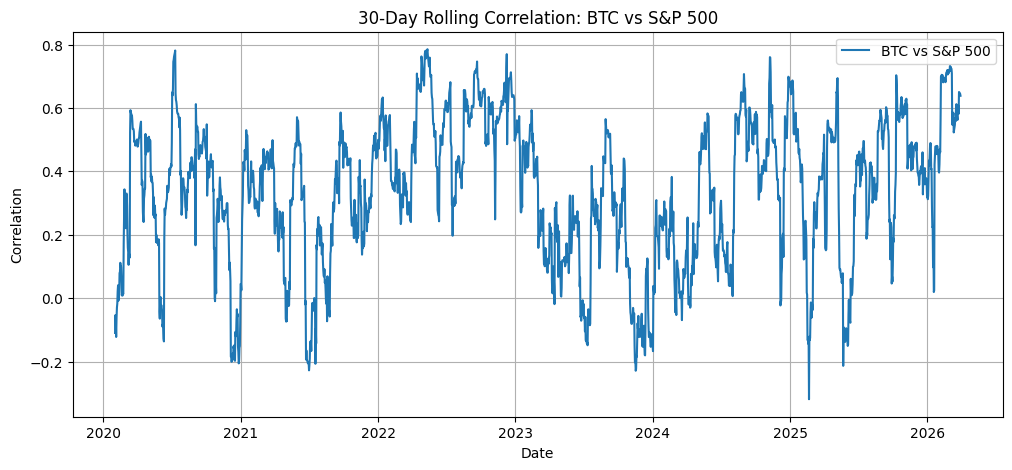

In [102]:
rolling_corr = returns['BTC'].rolling(window=30).corr(returns['SP500'])

plt.figure(figsize=(12,5))
plt.plot(rolling_corr, label='BTC vs S&P 500')
plt.title('30-Day Rolling Correlation: BTC vs S&P 500')
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.legend()
plt.grid(True)
plt.show()

## Hypothesis Testing

H0: There is no correlation between Bitcoin and the S&P 500  
H1: There is a significant correlation

In [103]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(returns['BTC'].values, returns['SP500'].values)

print("Correlation:", round(corr, 4))
print("P-value:", "{:.2e}".format(p_value))

Correlation: 0.3579
P-value: 7.78e-70


### Interpretation

The correlation between Bitcoin and the S&P 500 is approximately 0.36, indicating a moderate positive relationship. This suggests that Bitcoin tends to move in the same direction as the stock market.

The p-value is extremely small (7.78e-70), indicating that the result is statistically significant. Therefore, we reject the null hypothesis and conclude that there is a meaningful relationship between Bitcoin and the S&P 500.

These findings suggest that Bitcoin behaves more like a risk asset rather than a safe-haven asset over the observed time period.

This directly supports the research question regarding whether Bitcoin behaves more like a traditional financial asset.

If the p-value is less than 0.05, we reject the null hypothesis and conclude that there is a statistically significant relationship.

Otherwise, we fail to reject the null hypothesis.

In [104]:
corr_gold, p_value_gold = pearsonr(returns['BTC'], returns['Gold'])

print("BTC vs Gold Correlation:", corr_gold)
print("P-value:", p_value_gold)

BTC vs Gold Correlation: 0.09796471287469277
P-value: 2.79368827002296e-06


### BTC vs Gold Interpretation

The correlation between Bitcoin and Gold is lower compared to the S&P 500, indicating a weaker relationship. This suggests that Bitcoin does not consistently behave like a traditional safe-haven asset.

The statistical significance of this relationship depends on the p-value. Based on the results, Bitcoin appears to have a weaker and less stable connection with Gold compared to equities.

## Final Conclusion

The analysis indicates that Bitcoin has a moderate positive correlation with the S&P 500 and a weaker relationship with Gold. The statistical tests confirm that the relationship with the S&P 500 is significant, suggesting that Bitcoin behaves more like a risk asset rather than a traditional safe-haven asset.

These findings contribute to understanding Bitcoin’s role in modern financial markets and provide a foundation for further analysis using machine learning techniques.